In [1]:
import ase.units as units
from ase.build import molecule
from ase.calculators.tip3p import TIP3P
from ase.constraints import FixBondLengths
from ase.io.trajectory import Trajectory
from ase.md import Langevin

import matplotlib.pyplot as plt 
from ase.visualize.plot import plot_atoms 

In [2]:
# initialise and equilibrate water box 
water_molecules = molecule('H2O') # creating water molecule
density = 0.9982  # denisty of water in g/cm^3 at 20°C
box_length = ((water_molecules.get_masses().sum() / units.mol) / (density * 1e-24)) ** (
    1 / 3
)  # box length in Å
water_molecules.set_cell((box_length, box_length, box_length))
water_molecules.center()
# Repeat the water molecule we just created to end up with a PBC cell
water_molecules *= (3, 3, 3)
water_molecules.set_pbc(True)

water_molecules.constraints = FixBondLengths(
    [(3 * i + j, 3 * i + (j + 1) % 3) for i in range(3**3) for j in [0, 1, 2]]
)
# RATTLE-type constraints on O-H1, O-H2, H1-H2.
tag = 'tip3p_27mol_equil'
water_molecules.calc = TIP3P(rc=4.5)  # set the calculator to be the TIP3P force field

# Equillibrate in a small box first.
md = Langevin(
    water_molecules,
    1 * units.fs,
    temperature_K=293.15,  # 20 °C
    friction=0.01,
    logfile=tag + '.log',
)

traj = Trajectory(tag + '.traj', 'w', water_molecules)
md.attach(traj.write, interval=1)
md.run(4)  # please use 4000 to better equilibrate

# Repeat box and equilibrate further.
tag = 'tip3p_216mol_equil'
water_molecules.set_constraint()  # repeat not compatible with FixBondLengths currently.
water_molecules *= (2, 2, 2)
water_molecules.constraints = FixBondLengths(
    [
        (3 * i + j, 3 * i + (j + 1) % 3)
        for i in range(len(water_molecules) // 3)
        for j in [0, 1, 2]
    ]
)
water_molecules.calc = TIP3P(rc=7.0)

md = Langevin(
    water_molecules,
    2 * units.fs,
    temperature_K=293.15,  # 20 °C
    friction=0.01,
    logfile=tag + '.log',
)

traj = Trajectory(tag + '.traj', 'w', water_molecules)
md.attach(traj.write, interval=1)
md.run(2)  # please use 2000 to better equilibrate

/home/fh22600/miniforge3/envs/testing/lib/python3.14/site-packages/ase/md/langevin.py:110: FutureWarning: The implementation of `fixcm=True` in `Langevin` does not strictly sample the correct NVT distributions. The deviations are typically small for large systems but can be more pronounced for small systems. Use `fixcm=False` together with `ase.constraints.FixCom`. `fixcm` is deprecated since ASE 3.28.0 and will be removed in a future release.
  warnings.warn(msg, FutureWarning)


True

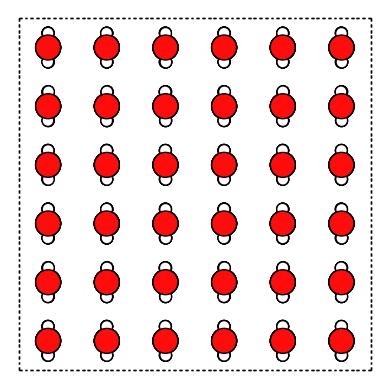

In [3]:
fig, ax = plt.subplots()
plot_atoms(water_molecules, ax)
ax.set_axis_off()

running a NVE simulation of equilibrated water 
Energy per atom: Epot =40.444eV  Ekin = 17.417eV (T=311.900K) Etot = 57.861eV
Energy per atom: Epot =40.214eV  Ekin = 17.647eV (T=316.024K) Etot = 57.861eV
Energy per atom: Epot =39.493eV  Ekin = 18.370eV (T=328.979K) Etot = 57.863eV
Energy per atom: Epot =38.144eV  Ekin = 19.722eV (T=353.185K) Etot = 57.866eV
Energy per atom: Epot =35.961eV  Ekin = 21.907eV (T=392.320K) Etot = 57.868eV
Energy per atom: Epot =32.704eV  Ekin = 25.166eV (T=450.674K) Etot = 57.869eV
Energy per atom: Epot =28.158eV  Ekin = 29.709eV (T=532.039K) Etot = 57.868eV
Energy per atom: Epot =22.218eV  Ekin = 35.644eV (T=638.312K) Etot = 57.862eV
Energy per atom: Epot =14.952eV  Ekin = 42.898eV (T=768.228K) Etot = 57.850eV
Energy per atom: Epot = 6.659eV  Ekin = 51.175eV (T=916.446K) Etot = 57.833eV
Energy per atom: Epot =-2.112eV  Ekin = 59.924eV (T=1073.136K) Etot = 57.812eV
Energy per atom: Epot =-10.616eV  Ekin = 68.406eV (T=1225.027K) Etot = 57.790eV
Energy per at

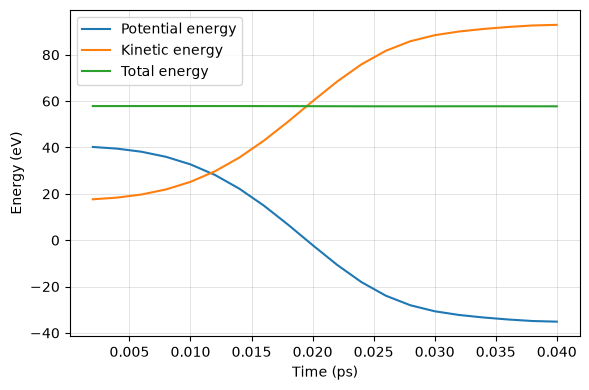

In [4]:
import matplotlib.pyplot as plt
import numpy as np

# choose one of the following implementations of EMT:
# included in ase
# from ase.calculators.emt import EMT
# faster performance
from asap3 import EMT
from ase.calculators.tip4p import TIP3P
from ase import units

from ase.io.trajectory import Trajectory

from ase.md.velocitydistribution import (
    MaxwellBoltzmannDistribution,
    Stationary,
    ZeroRotation,
)
from ase.md.verlet import VelocityVerlet
from ase.optimize import QuasiNewton
from ase.visualize.plot import plot_atoms



# Describe the interatomic interactions with the Effective Medium Theory (EMT)
water_molecules.calc = TIP3P()

# Set the initial velocities corresponding to T=300K from Maxwell Boltzmann
# Distribution
MaxwellBoltzmannDistribution(water_molecules, temperature_K=300)


timestep_fs = 1
dyn = VelocityVerlet(water_molecules, timestep_fs * units.fs)  # 1 fs time step.

def printenergy(a):
    """
    Function to print the thermodynamical properties i.e potential energy,
    kinetic energy and total energy
    """
    epot = a.get_potential_energy()
    ekin = a.get_kinetic_energy()
    temp = a.get_temperature()
    print(
        f'Energy per atom: Epot ={epot:6.3f}eV  Ekin = {ekin:.3f}eV '
        f'(T={temp:.3f}K) Etot = {epot + ekin:.3f}eV'
    )

# Now run the dynamics
print('running a NVE simulation of equilibrated water ')
printenergy(water_molecules)
# init lists to for energy vs time data
time_ps, epot, ekin = [], [], []
mdind = 0
steps_per_block = 2
for i in range(20):
    dyn.run(steps_per_block)
    mdind += steps_per_block
    printenergy(water_molecules)
    # save the energies of the current MD step
    time_ps.append(mdind * timestep_fs / 1000.0)
    epot.append(water_molecules.get_potential_energy())
    ekin.append(water_molecules.get_kinetic_energy())

etot = np.array(epot) + np.array(ekin)

# Plot energies vs time
fig, ax = plt.subplots(figsize=(6, 4))
ax.plot(time_ps, epot, label='Potential energy')
ax.plot(time_ps, ekin, label='Kinetic energy')
ax.plot(time_ps, etot, label='Total energy')
ax.set_xlabel('Time (ps)')
ax.set_ylabel('Energy (eV)')
ax.legend(loc='best')
ax.grid(True, linewidth=0.5, alpha=0.5)
plt.tight_layout()
plt.show()
